In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [54]:
mat = loadmat("ex3data1.mat")
x= mat['X']
y= mat['y']
print("Format de X:", x.shape)
print("Format de y:", y.shape)

Format de X: (5000, 400)
Format de y: (5000, 1)


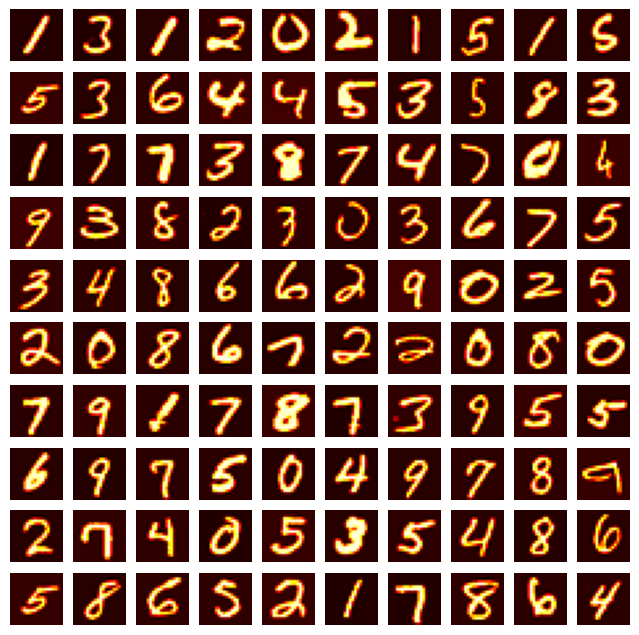

In [55]:
fig,axis = plt.subplots(10,10,figsize=(8,8))
for i in range(10):
    for j in range(10):
        axis[i,j].imshow(x[np.random.randint(0,5001),:].reshape(20,20,order="F"), cmap="hot")
        axis[i,j].axis("off")

In [56]:
# Para transformar em binário
def sigmoid(z):
    return 1/(1+np.exp(-z))

def sigmoid_gradient(z):
    sigmoid = 1/(1+np.exp(-z))
    return sigmoid * (1 - sigmoid)

def computeCost(X, y, theta, input_layer_size, hidden_layer_size, num_labels, Lambda):
    theta1 = theta[:((input_layer_size + 1) * hidden_layer_size)].reshape(hidden_layer_size, input_layer_size + 1)
    theta2 = theta[((input_layer_size + 1) * hidden_layer_size):].reshape(num_labels, hidden_layer_size + 1)  # CORRIGIDO
    m = X.shape[0]
    J = 0
    X = np.hstack((np.ones((m, 1)), X))  # CORRIGIDO: tupla (m,1)
    y10 = np.zeros((m, num_labels))

    a1 = sigmoid(X @ theta1.T)
    a1 = np.hstack((np.ones((m, 1)), a1))
    a2 = sigmoid(a1 @ theta2.T)

    # Cria matriz one-hot encoding
    for i in range(1, num_labels + 1):
        y10[:, i-1][:, np.newaxis] = np.where(y == i, 1, 0)
    
    # Calcula o custo não regularizado
    for j in range(num_labels):
        J = J + sum(-y10[:, j] * np.log(a2[:, j]) - (1 - y10[:, j]) * np.log(1 - a2[:, j]))
    cost = 1/m * J
    
    # Custo com regularização
    reg_J = cost + Lambda/(2*m) * (np.sum(theta1[:, 1:]**2) + np.sum(theta2[:, 1:]**2))

    grad1 = np.zeros((theta1.shape))
    grad2 = np.zeros((theta2.shape))

    # Backpropagation
    for i in range(m):
        xi = X[i, :]
        a1i = a1[i, :]
        a2i = a2[i, :]
        d2 = a2i - y10[i, :]
        d1 = theta2.T @ d2.T * sigmoid_gradient(np.hstack((1, xi @ theta1.T)))
        grad1 = grad1 + d1[1:][:, np.newaxis] @ xi[:, np.newaxis].T
        grad2 = grad2 + d2.T[:, np.newaxis] @ a1i[:, np.newaxis].T

    grad1 = 1/m * grad1
    grad2 = 1/m * grad2

    # Adiciona regularização nos gradientes
    grad1_reg = grad1 + (Lambda/m) * np.hstack((np.zeros((theta1.shape[0], 1)), theta1[:, 1:]))  # CORRIGIDO: zeros
    grad2_reg = grad2 + (Lambda/m) * np.hstack((np.zeros((theta2.shape[0], 1)), theta2[:, 1:]))  # CORRIGIDO: zeros e grad2

    return cost, grad1, grad2, reg_J, grad1_reg, grad2_reg


In [57]:
def randInitializeWeights(L_in, L_out):
    epi=(6**1/2)/(L_in + L_out)**1/2 # calcula epsilon para a inicialização aleatória dos pesos
    W= np.random.rand(L_out, L_in + 1)*2*epi - epi #inicializa pesos aleatórios no intervalo [-epsilon, epsilon]
    return W  # Retorna a matriz de pesos inicializados aleatoriamente

In [58]:
def gradientDescent(X, y, theta, alpha, nbr_iter, Lambda, input_layer_size, hidden_layer_size, num_labels):
    theta1 = theta[:((input_layer_size + 1) * hidden_layer_size)].reshape(hidden_layer_size, input_layer_size + 1)
    theta2 = theta[((input_layer_size + 1) * hidden_layer_size):].reshape(num_labels, hidden_layer_size + 1)  # CORRIGIDO
    m = len(y)
    J_history = []
    
    for i in range(nbr_iter):  # CORRIGIDO: indentação
        theta = np.append(theta1.flatten(), theta2.flatten())
        cost, grad1, grad2 = computeCost(X, y, theta, input_layer_size, hidden_layer_size, num_labels, Lambda)[3:]
        theta1 = theta1 - (alpha * grad1)  # CORRIGIDO: indentação
        theta2 = theta2 - (alpha * grad2)  # CORRIGIDO: indentação
        J_history.append(cost)  # CORRIGIDO: indentação
    
    nn_paramsFinal = np.append(theta1.flatten(), theta2.flatten())
    return nn_paramsFinal, J_history

In [59]:
def predict(X,theta1,theta2):
  m= X.shape[0]
  X=np.hstack((np.ones((m,1)),X)) #adiciona coluna de 1s para o bias na camada de entrada

  a1=sigmoid(X@theta1.T)
  a1= np.hstack((np.ones((m,1)),a1))
  a2= sigmoid(a1@theta2.T) #calcula ativação de camada de saída (predições)

  return np.argmax(a2,axis=1) + 1 #retorna a classe com maior probabilidade (+1 se classes começam em 1)

In [60]:
# Uso correto:
input_layer_size = 400
hidden_layer_size = 25
num_labels = 10

initial_theta1 = randInitializeWeights(input_layer_size, hidden_layer_size)
initial_theta2 = randInitializeWeights(hidden_layer_size, num_labels)

initial_theta = np.append(initial_theta1.flatten(), initial_theta2.flatten())

# CORRIGIDO: Use 'x' e 'y' (minúsculas) como definido no carregamento
theta, J_history = gradientDescent(x, y, initial_theta, 0.8, 800, 1, input_layer_size, hidden_layer_size, num_labels)

# Separa os pesos finais
theta1 = theta[:((input_layer_size + 1) * hidden_layer_size)].reshape(hidden_layer_size, input_layer_size + 1)
theta2 = theta[((input_layer_size + 1) * hidden_layer_size):].reshape(num_labels, hidden_layer_size + 1)

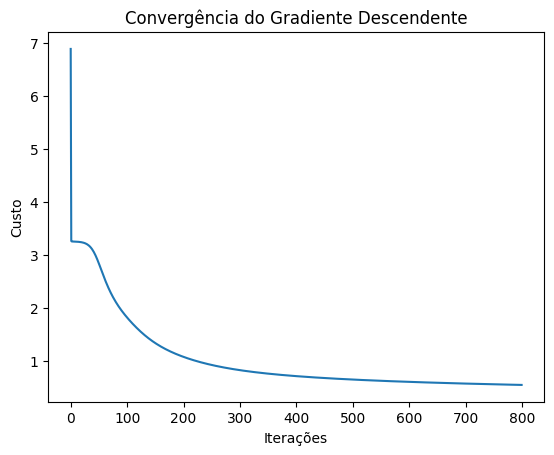

Acurácia no treino: 93.84%


In [61]:
# Plotar histórico do custo
plt.plot(J_history)
plt.xlabel('Iterações')
plt.ylabel('Custo')
plt.title('Convergência do Gradiente Descendente')
plt.show()

# Fazer predições
predictions = predict(x, theta1, theta2)
accuracy = np.mean(predictions == y.flatten()) * 100
print(f"Acurácia no treino: {accuracy:.2f}%")